## Installation des dépendances

In [1]:
!pip install torch torchaudio transformers librosa scikit-learn matplotlib seaborn tqdm soundfile -q

## Imports

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import ASTModel, ASTFeatureExtractor
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import gc

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
# Kaggle input 
DATA_DIR = "/kaggle/input/datasets/yacoubsana/icbhi-final-database/ICBHI_final_database/ICBHI_final_database"
SPLIT_FILE = "/kaggle/input/datasets/yacoubsana/icbhi-final-database/ICBHI_challenge_train_test.txt"

# Kaggle working directory (WRITE OK)
WORK_DIR = "/kaggle/working"

# Créer dossiers pour outputs
os.makedirs(f"{WORK_DIR}/data", exist_ok=True)
os.makedirs(f"{WORK_DIR}/checkpoints", exist_ok=True)

## Prétraitement des données
- Tous les audios sont resamplés à 16 kHz
- Chaque extrait fera 8 secondes
- Donc : 16000 × 8 = 128000 samples
- Les segments respiratoires ont durée variable : Si trop court → on répète le signal -> Cyclic padding

In [4]:
TARGET_SR = 16000       # Fréquence d'échantillonnage
TARGET_DURATION = 8     # Durée cible en secondes
TARGET_SAMPLES = TARGET_SR * TARGET_DURATION  # 128000 échantillons

# Mapping des stéthoscopes (Device ID)
DEVICE_MAP = {'AKGC417L': 0, 'LittC2SE': 1, 'Litt3200': 2, 'Meditron': 3}

def get_device_id(filename):
    """Extrait l'ID du stéthoscope depuis le nom du fichier."""
    dev_name = filename.split('_')[-1]
    return DEVICE_MAP.get(dev_name, -1)

def cyclic_padding(wav, target_len):
    """Répète le signal en boucle pour atteindre target_len échantillons."""
    if len(wav) >= target_len:
        return wav[:target_len]
    repeat_count = (target_len // len(wav)) + 1
    return np.tile(wav, repeat_count)[:target_len]


- Chargement audio et annotations
- Découpage en segments respiratoires
- Supprime segments invalides
- Uniformise longueur (8s)
- Encode labels (4 classes)
- Ajoute info stéthoscope
- Split train/test

In [5]:
NPZ_PATH = "/kaggle/working/icbhi_preprocessed.npz"

# processing function
def process_data():
    split_df = pd.read_csv(SPLIT_FILE, sep='\t', names=['filename', 'set_type'])

    X_train, y_train, device_train = [], [], []
    X_test, y_test, device_test = [], [], []

    skipped = 0

    stats = {'Normal': 0, 'Crackle': 0, 'Wheeze': 0, 'Both': 0}

    for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
        fname, set_type = row['filename'], row['set_type']

        wav_path = os.path.join(DATA_DIR, fname + '.wav')
        txt_path = os.path.join(DATA_DIR, fname + '.txt')

        # Vérification fichiers
        if not os.path.exists(wav_path) or not os.path.exists(txt_path):
            skipped += 1
            continue
        #Chargement audio
        audio, _ = librosa.load(wav_path, sr=TARGET_SR)

        dev_id = get_device_id(fname)
        #Chargement annotations
        anns = pd.read_csv(txt_path, sep='\t',
                           names=['start', 'end', 'crackle', 'wheeze'])
        #Découpage en segments respiratoires
        for _, ann in anns.iterrows():
            start = int(ann['start'] * TARGET_SR)
            end = int(ann['end'] * TARGET_SR)

            chunk = audio[start:end]
            #Filtrage des segments trop courts
            if len(chunk) < 100:
                continue
            
            # --- CYCLIC PADDING ---
            #Normalisation de taille
            processed_wav = cyclic_padding(chunk, TARGET_SAMPLES)

            # Label encoding
            c, w = ann['crackle'], ann['wheeze']
            if c == 0 and w == 0:
                label = 0
                stats['Normal'] += 1
            elif c == 1 and w == 0:
                label = 1
                stats['Crackle'] += 1
            elif c == 0 and w == 1:
                label = 2
                stats['Wheeze'] += 1
            else:
                label = 3
                stats['Both'] += 1

            if set_type == 'train':
                X_train.append(processed_wav)
                y_train.append(label)
                device_train.append(dev_id)
            else:
                X_test.append(processed_wav)
                y_test.append(label)
                device_test.append(dev_id)

    print(f" Fichiers ignorés: {skipped}")

    return (
        np.array(X_train, dtype=np.float32),
        np.array(y_train, dtype=np.int64),
        np.array(device_train, dtype=np.int64),
        np.array(X_test, dtype=np.float32),
        np.array(y_test, dtype=np.int64),
        np.array(device_test, dtype=np.int64)
    )

# Load or preprocess
if os.path.exists(NPZ_PATH):
    print(" Loading cached dataset...")
    data = np.load(NPZ_PATH)

    X_train = data['X_train']
    y_train = data['y_train']
    d_train = data['d_train']
    X_test = data['X_test']
    y_test = data['y_test']
    d_test = data['d_test']

else:
    print(" Processing dataset (first time)...")
    X_train, y_train, d_train, X_test, y_test, d_test = process_data()

    np.savez(
        NPZ_PATH,
        X_train=X_train, y_train=y_train, d_train=d_train,
        X_test=X_test, y_test=y_test, d_test=d_test
    )
    print("Saved to /kaggle/working")


print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Label distribution (train): {np.bincount(y_train)}")

 Processing dataset (first time)...


100%|██████████| 920/920 [01:03<00:00, 14.47it/s]


 Fichiers ignorés: 1
Saved to /kaggle/working
Train shape: (4131, 128000)
Test shape: (2756, 128000)
Label distribution (train): [2057 1210  501  363]


## Chargement des données et extraction des variables

In [6]:
data = np.load(NPZ_PATH)
#labels (0 à 3)
y_train = data['y_train']
y_test  = data['y_test']
#signaux audio
X_train = data['X_train']
X_test  = data['X_test']
#device IDs
d_train = data['d_train']
d_test = data['d_test']

y= np.concatenate([y_train, y_test])
x=np.concatenate([X_train, X_test])
counts = np.bincount(y)
print("les labels",y)
print("Distribution des classes [Normal Crackle Wheeze Both]:", counts)

les labels [2 0 2 ... 0 0 0]
Distribution des classes [Normal Crackle Wheeze Both]: [3636 1859  886  506]


## Définition du Modèle

### Optimiseur SAM (Sharpness-Aware Minimization)
SAM cherche des minima plats dans la loss landscape pour une meilleure généralisation.

Il fait 2 passes par batch : perturber les poids (pire cas) puis optimiser.

In [7]:
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho, adaptive=False, **kwargs):
        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                self.state[p]["old_p"] = p.data.clone()
                e_w = (torch.pow(p, 2) if group["adaptive"] else 1.0) * p.grad * scale.to(p)
                p.add_(e_w)
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.data = self.state[p]["old_p"]
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        norm = torch.norm(torch.stack([
            ((torch.abs(p) if group["adaptive"] else 1.0) * p.grad).norm(p=2).to(shared_device)
            for group in self.param_groups for p in group["params"]
            if p.grad is not None
        ]), p=2)
        return norm



### Dataset PyTorch
Transformer les signaux audio bruts en entrées exploitables par le modèle AST

audio brut → spectrogramme → tokens transformer

-> le processor transforme un son brut en représentation que le Transformer peut lire comme une séquence de patches

In [8]:
class ASTDataset(Dataset):
    def __init__(self, X, y, device_ids, processor, train=True):
        self.X, self.y, self.device_ids = X, y, device_ids
        self.processor, self.train = processor, train

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        #récupérer l’audio
        wav = self.X[idx]
        #Data augmentation
        if self.train:
            #variation d’amplitude
            if np.random.random() < 0.5:
                wav = wav * np.random.uniform(0.9, 1.1)
            #bruit léger
            if np.random.random() < 0.5:
                wav = wav + np.random.normal(0, 0.0001, wav.shape)
        #transforme le son brut en représentation que le Transformer peut lire (spectrogramme + patches)
        inputs = self.processor(wav, sampling_rate=16000, return_tensors="pt")
        input_values = inputs.input_values.squeeze(0)
        return input_values, torch.tensor(self.y[idx], dtype=torch.long), self.device_ids[idx]



### Modèle CustomAST
Audio brut -> AST (compréhension du son) -> embedding (768 features) -> classifier -> 4 classes

In [9]:
class CustomAST(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.ast = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        #modèle audio pré-entraîné
        outputs = self.ast(x)
        #extraction des embeddings
        embeddings = outputs.last_hidden_state.mean(dim=1)
        #classification
        logits = self.classifier(embeddings)
        return logits



##  Entraînement
- **SAM + AdamW** : optimiseur avec 2 passes par batch
- **WeightedRandomSampler** : compense le déséquilibre des classes
- **Label Smoothing** : empêche le modèle d'être trop confiant
- Les modifications réalisées :
- Problème 1 : SAM est instable si gradients trop grands / Solution : on limite le gradient
- Problème 2 : Paramètre : rho qui représente “force de perturbation” peut être petit ou pas optimal donc on le règle

In [10]:
# Hyperparamètres
EPOCHS = 10
BATCH_SIZE = 8
LR = 1e-5
CHECKPOINT_DIR = "/kaggle/working/checkpoints"

# Processor et DataLoaders
processor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

counts = np.bincount(y_train)
#donner plus d’importance aux classes rares
weights = [1.0/counts[y] for y in y_train]
sampler = WeightedRandomSampler(weights, len(y_train))

train_loader = DataLoader(ASTDataset(X_train, y_train, d_train, processor, train=True),
                          batch_size=BATCH_SIZE, sampler=sampler)
test_loader = DataLoader(ASTDataset(X_test, y_test, d_test, processor, train=False),
                         batch_size=BATCH_SIZE, shuffle=False)

# Modèle, Optimiseur, Loss
model = CustomAST(num_classes=4).to(DEVICE)
optimizer = SAM(model.parameters(), torch.optim.AdamW, lr=LR, rho=0.1, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print(f"Prêt : {sum(p.numel() for p in model.parameters())/1e6:.1f}M paramètres")

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Prêt : 86.2M paramètres


In [11]:
# Boucle d'entraînement
start_epoch = 0
best_score = 0.0

CKPT_PATH = os.path.join(CHECKPOINT_DIR, "last_checkpoint.pth")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pth")

if os.path.exists(CKPT_PATH):
    print(" Reprise depuis checkpoint...")
    checkpoint = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.base_optimizer.load_state_dict(checkpoint["optimizer_state"])

    start_epoch = checkpoint["epoch"]
    best_score = checkpoint["best_score"]

    print(f" Repris à l'époque {start_epoch} | Best score = {best_score:.4f}")
else:
    print(" Entraînement depuis zéro")

for epoch in range(start_epoch, EPOCHS):
    model.train()
    running_loss = 0.0
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for inputs, labels, _ in progress:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        # SAM Step 1 : perturbation (pire cas)
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        #empêche les gradients explosifs
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.first_step(zero_grad=True)

        # SAM Step 2 : vraie mise à jour
        criterion(model(inputs), labels).backward()
        optimizer.second_step(zero_grad=True)

        running_loss += loss.item()
        progress.set_postfix({'Loss': loss.item()})

    # Évaluation à chaque époque
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels, _ in test_loader:
            preds = torch.argmax(model(inputs.to(DEVICE)), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    se = np.sum(cm[1:, 1:]) / np.sum(cm[1:, :]) if np.sum(cm[1:, :]) > 0 else 0
    sp = cm[0, 0] / np.sum(cm[0, :]) if np.sum(cm[0, :]) > 0 else 0
    score = (se + sp) / 2

    print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f} | "
          f"Se={se:.4f} | Sp={sp:.4f} | Score={score:.4f}")

# ================== SAVE BEST MODEL ==================
    if score > best_score:
        best_score = score
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"    --> Meilleur modèle sauvegardé ({best_score:.4f})")

    # ================== SAVE CHECKPOINT ==================
    checkpoint = {
        "epoch": epoch + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.base_optimizer.state_dict(),
        "best_score": best_score
    }

    # Sauvegarde sécurisée (évite corruption)
    torch.save(checkpoint, CKPT_PATH + ".tmp")
    os.replace(CKPT_PATH + ".tmp", CKPT_PATH)


print(f"\n✅ Meilleur Score final: {best_score:.4f}")

 Entraînement depuis zéro


Epoch 1: Loss=1.1068 | Se=0.8879 | Sp=0.3059 | Score=0.5969
    --> Meilleur modèle sauvegardé (0.5969)


Epoch 2: Loss=0.9082 | Se=0.8879 | Sp=0.3148 | Score=0.6013
    --> Meilleur modèle sauvegardé (0.6013)


Epoch 3: Loss=0.8339 | Se=0.8471 | Sp=0.4110 | Score=0.6290
    --> Meilleur modèle sauvegardé (0.6290)


Epoch 4: Loss=0.7390 | Se=0.8564 | Sp=0.4041 | Score=0.6302
    --> Meilleur modèle sauvegardé (0.6302)


Epoch 5: Loss=0.6996 | Se=0.7850 | Sp=0.4465 | Score=0.6158


Epoch 6: Loss=0.6456 | Se=0.8105 | Sp=0.4497 | Score=0.6301


Epoch 7: Loss=0.5983 | Se=0.7545 | Sp=0.5003 | Score=0.6274


KeyboardInterrupt: 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sensitivity (Se): 85.47%
Specificity (Sp): 40.41%
ICBHI Score:       62.94%


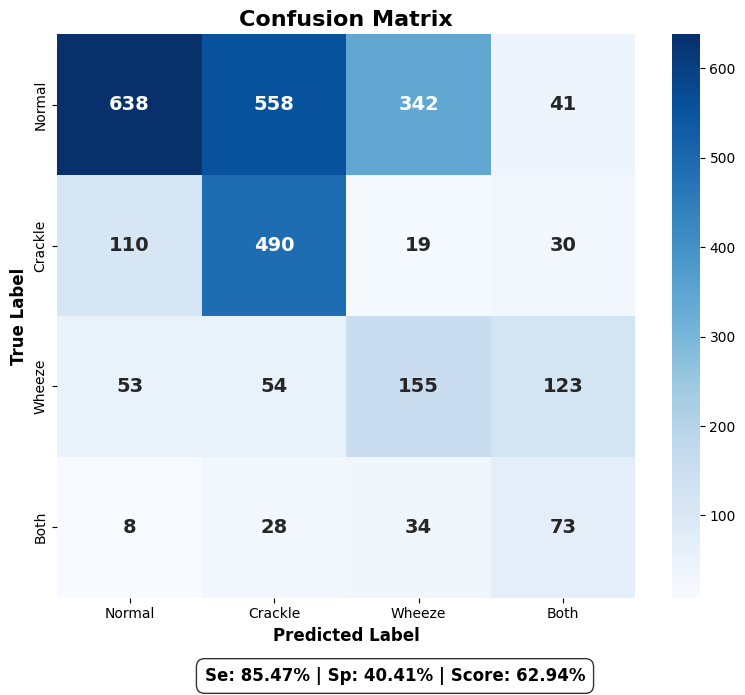

Matrice de confusion sauvegardée.


In [12]:
# Charger le meilleur modèle
gc.collect()
torch.cuda.empty_cache()
model = CustomAST(num_classes=4).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best_model.pth"), map_location=DEVICE))
model.eval()

CLASSES = ['Normal', 'Crackle', 'Wheeze', 'Both']
all_preds, all_targets = [], []

with torch.no_grad():
    for inputs, labels, _ in test_loader:
        inputs = inputs.to(DEVICE)
        if DEVICE.type == 'cuda':
            with torch.amp.autocast('cuda'):
                preds = torch.argmax(model(inputs), dim=1)
        else:
            preds = torch.argmax(model(inputs), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

cm = confusion_matrix(all_targets, all_preds)
se = np.sum(cm[1:, 1:]) / np.sum(cm[1:, :])
sp = cm[0, 0] / np.sum(cm[0, :])
score = (se + sp) / 2

print(f"Sensitivity (Se): {se*100:.2f}%")
print(f"Specificity (Sp): {sp*100:.2f}%")
print(f"ICBHI Score:       {score*100:.2f}%")

# Matrice de confusion
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            annot_kws={"size": 14, "weight": "bold"})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
metrics_text = f"Se: {se*100:.2f}% | Sp: {sp*100:.2f}% | Score: {score*100:.2f}%"
plt.figtext(0.5, 0.02, metrics_text, ha='center', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.5'))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()
print("Matrice de confusion sauvegardée.")

- La loss diminue correctement (1.10 → 0.59) → le modèle apprend et converge sans instabilité.
- Bonne sensibilité (Se élevée ~85%) → le modèle détecte bien les classes anormales (peu de faux négatifs).
- Spécificité faible (~40–50%) → présence de nombreux faux positifs → tendance à sur-prédire les anomalies.
- Déséquilibre entre Se et Sp → modèle biaisé vers la détection positive (classique avec des datasets déséquilibrés comme ICBHI).
- Score global (~63%) progresse au début puis se stabilise → plateau atteint vers les epochs 3–4.
- Après l’epoch 4, peu d’amélioration → possible début de surapprentissage ou limite du modèle / des features.